In [46]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from pprint import pprint

from functools import partial

import numpy as np
from sklearn.preprocessing import scale
import sklearn.metrics as metrics

import matplotlib.pyplot as plt
import matplotlib.animation as ani

import mlgrad.models as models
import mlgrad.regr as regr
import mlgrad.cls as cls
import mlgrad.pca as pca
import mlgrad.plots as plots
import mlgrad.funcs as funcs
import mlgrad.funcs2 as funcs2
import mlgrad.loss as loss
import mlgrad.gd as gd
import mlgrad.smooth as smooth
import mlgrad.inventory as inventory
from mlgrad.af import averaging_function
import mlgrad.avragg as avragg

import rampy
import pybaselines
import random

from irsa import io
from irsa.preprocess import despike, utils
import irsa.widgets as widgets
import irsa.spectra as spectra
import irsa.io as io

import scipy.special as special

import copy

import ipywidgets
from IPython.display import display

import sys
print(sys.version)

# %matplotlib widget

3.13.11 (main, Dec  8 2025, 11:43:54) [GCC 15.2.0]


In [47]:
def plot_spectra2(XX, YY, ax=None):
    if ax is None:
        ax = plt.gca()
    XX1 = XX[YY == 1]
    XX2 = XX[YY == -1]
    ax.plot(np.mean(XX1, axis=0), color='r', linewidth=0.75, label='191', alpha=0.25)
    ax.plot(np.mean(XX2, axis=0), color='b', linewidth=0.75, label='191', alpha=0.25)
    
    # for item_191, item_606 in zip(d_191, d_606):
    #     ax.plot(np.mean(item_191[2], axis=0), color='r', linewidth=1.0, label='191', alpha=0.25)
    #     ax.plot(np.mean(item_606[2], axis=0), color='b', linewidth=1.0, label='606', alpha=0.25)
    # ax.legend(loc="upper left")
    ax.set_xlabel("$k$ (индекс точки)")
    ax.set_ylabel("Интенсивность (нормированная)")
    ax.set_title("Спектры (усредненные) по классам и значения коэффициентов")
    ax.minorticks_on()

def plot_params(param, ax=None):
    pp = np.asarray(param)
    pp = pp[1:]
    ymax = np.asarray(pp.copy())
    ymin = np.asarray(pp.copy())
    np.putmask(ymax, ymax<0, 0)
    np.putmask(ymin, ymax>0, 0)
    n = len(ymin)
    nz = (abs(pp) != 0).sum()
    plt.vlines(range(n), ymin, ymax, color='k', linewidth=1., label=f"кол-во коэфф. != 0 -> {nz}")
    plt.minorticks_on()
    plt.ylabel(r"$w_k$")
    # ax.legend(loc="upper right")


In [48]:
d = spectra.SpectraCollection()
d.load("/home/intellimath/work/spectra/12", "topf")

In [49]:
d.plot_spectra(0)

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20251117_SH_1…

In [50]:
d_SA = d.union(**{"вид_бактерий":"SA", "место":"edge"})
d_SS = d.union(**{"вид_бактерий":"SS", "место":"edge"})
d_SH = d.union(**{"вид_бактерий":"SH", "место":"edge"})
x = d_SA.x

In [51]:
d_SH.plot_spectra(0)

interactive(children=(IntSlider(value=0, description='i', layout=Layout(width='50%'), max=169), FloatRangeSlid…

In [52]:
y_SA = d_SA.y
y_SS = d_SS.y
y_SH = d_SH.y

y_SA_SS = np.vstack([y_SA, y_SS])
y_SA_SH = np.vstack([y_SA, y_SH])
y_SS_SH = np.vstack([y_SS, y_SH])

N_SA = y_SA.shape[0]
N_SS = y_SS.shape[0]
N_SH = y_SH.shape[0]
n = y_SA_SS.shape[1]

z_SA = np.ones(N_SA, "d")
z_SS = np.ones(N_SS, "d")
z_SH = np.ones(N_SH, "d")

z_SA_SS = np.concatenate([z_SA, -z_SS])
z_SA_SH = np.concatenate([z_SA, -z_SH])
z_SS_SH = np.concatenate([z_SS, -z_SH])

print(y_SA_SH.shape, z_SA_SH.shape)

(328, 803) (328,)


In [53]:
import mlgrad.models as models
import mlgrad.funcs as funcs
import mlgrad.funcs2 as funcs2
import mlgrad.loss as loss

import mlgrad.regr as regr
import mlgrad.af as af
import mlgrad.plots as plots

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score

In [54]:
def create_nn_model(n_hidden=10, tau=1.0):
    body = models.FFNetworkModel()
    ll = models.LinearLayer(n, n_hidden)
    ll.use_regularizer(funcs2.AbsoluteNorm(0), tau)
    body.add(ll)
    body.add(models.ScaleLayer(funcs.Sigmoidal(1.0), n_hidden))
    head = models.LinearModel(n_hidden)
    # head.use_regularizer(funcs2.AbsoluteNorm(0), tau)
    mod = models.FFNetworkFuncModel(head, body)
    mod.allocate()
    mod.init_param()
    return mod

def create_model(tau=0.1):
    # mod = models.SigmaNeuronModel(funcs.Sigmoidal(1.0), n)
    mod = models.LinearModel(n)
    mod.init_param()
    mod.use_regularizer(funcs2.AbsoluteNorm(1), tau)
    return mod

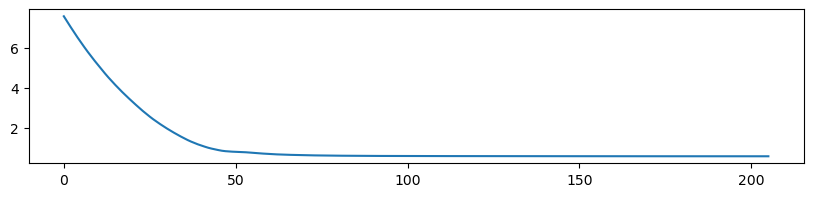

<mlgrad.funcs2.AbsoluteNorm object at 0x7fb75c691d90> 0.3
0.9359756097560976


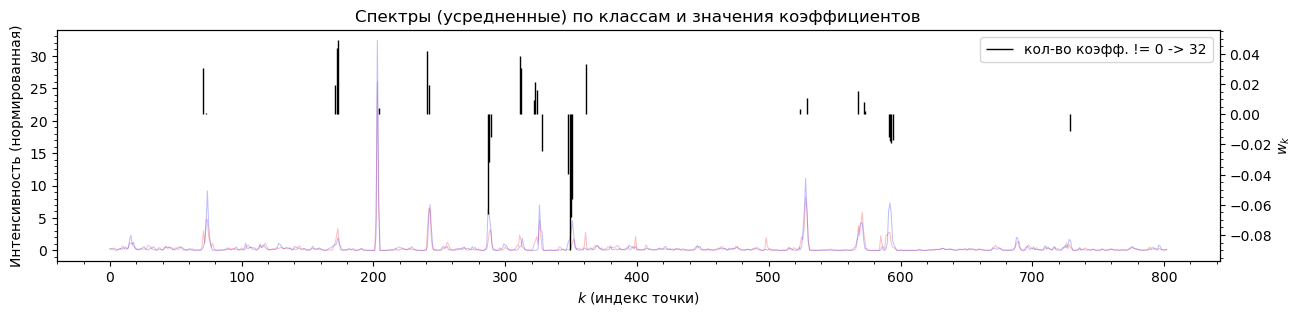

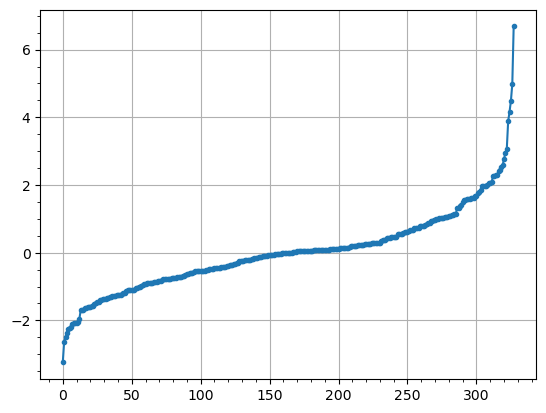

In [55]:
mod = create_model(0.3)
alg = regr.regression(y_SA_SH, z_SA_SH, mod, loss_func=loss.MarginLoss(funcs.Hinge(1.0)),
                                 # regnorm=funcs2.AbsoluteNorm(1), tau=0.3,
                                 normalizer=gd.Masked(mod.n_param, 1.0e-4), 
                                 h=0.001, n_iter=1000)
plt.figure(figsize=(10,2))
plt.plot(alg.lvals)
plt.show()

print(mod.regfunc, mod.tau)

print(accuracy_score(z_SA_SH, np.sign(mod.evaluate(y_SA_SH))))
# plots.plot_array_vlines(np.asarray(mod.param[1:]))
plt.figure(figsize=(15,3))
ax1 = plt.gca()
plot_spectra2(y_SA_SH, z_SA_SH, ax=ax1)
ax2 = plt.twinx(ax1)
plot_params(mod.param, ax=ax2)
plt.legend()
plt.show()

plt.plot(sorted(inventory.modified_zscore(z_SA_SH*mod.evaluate(y_SA_SH))), marker='o', markersize=3)
plt.minorticks_on()
plt.grid(1)
plt.show()

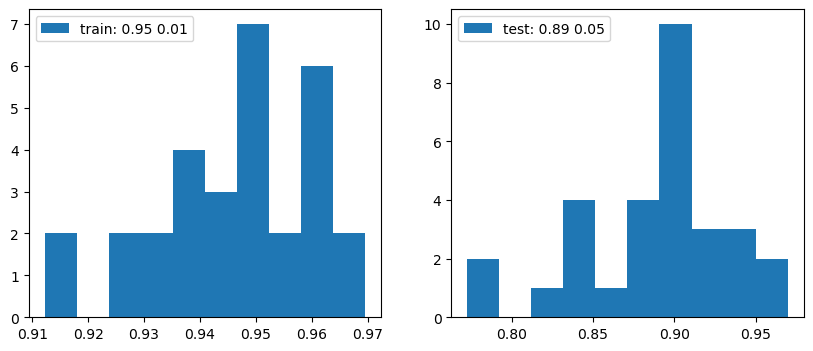

In [58]:
# cv = StratifiedKFold(5, shuffle=True)
cv = StratifiedShuffleSplit(30, test_size=0.2)
K = 1
t_score = []
c_score = []
for It, Ic in cv.split(y_SA_SH, z_SA_SH):
    mod = create_model(0.2)
    
    yy_t = y_SA_SH[It]
    zz_t = z_SA_SH[It]
    yy_c = y_SA_SH[Ic]
    zz_c = z_SA_SH[Ic]

    
    alg = regr.regression(yy_t, zz_t, mod, loss_func=loss.MarginLoss(funcs.Hinge(1.0)),
                                     # regnorm=funcs2.AbsoluteNorm(1), tau=0.002,
                                     normalizer=gd.Masked(mod.n_param, 1.0e-4), 
                                     h=0.001, n_iter=1000)
    t_score.append(accuracy_score(zz_t, np.sign(mod.evaluate(yy_t))))
    c_score.append(accuracy_score(zz_c, np.sign(mod.evaluate(yy_c))))
    # print()
    # plt.figure(figsize=(12,3))
    # plots.plot_array_vlines(np.asarray(mod.param[1:]))
    # plt.show()
    K += 1

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(t_score, 10, label=f"train: {np.mean(t_score):.2f} {np.std(t_score):.2f}")
plt.legend()
plt.subplot(1,2,2)
plt.hist(c_score, 10, label=f"test: {np.mean(c_score):.2f} {np.std(c_score):.2f}")
plt.legend()
plt.show()

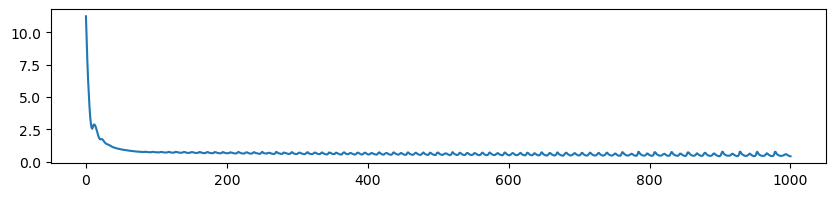

0.9390243902439024


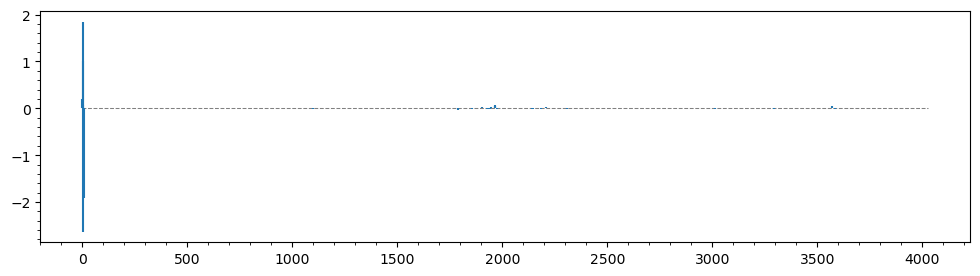

In [61]:
mod = create_nn_model(5, 0.1)
alg = regr.regression(y_SA_SH, z_SA_SH, mod, loss_func=loss.MarginLoss(funcs.Hinge(1.0)),
                                 # regnorm=funcs2.AbsoluteNorm(1), tau=0.1,
                                 normalizer=gd.Masked(mod.n_param, 1.0e-4), 
                                 h=0.005, n_iter=1000)
plt.figure(figsize=(10,2))
plt.plot(alg.lvals)
plt.show()

print(accuracy_score(z_SA_SH, np.sign(mod.evaluate(y_SA_SH))))
plt.figure(figsize=(12,3))
plots.plot_array_vlines(np.asarray(mod.param))
plt.show()


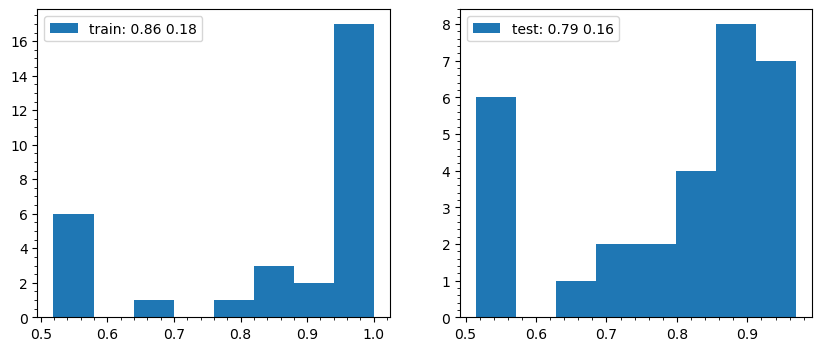

In [66]:
# cv = StratifiedKFold(5, shuffle=True)
cv = StratifiedShuffleSplit(30, test_size=0.2)
t_score = []
c_score = []

K = 1
for It, Ic in cv.split(y_SA_SH, z_SA_SH):
    mod = create_nn_model(10, 0.01)
    
    yy_t = y_SA_SH[It]
    zz_t = z_SA_SH[It]
    yy_c = y_SA_SH[Ic]
    zz_c = z_SA_SH[Ic]

    alg = regr.regression(yy_t, zz_t, mod, loss_func=loss.MarginLoss(funcs.Hinge(1.0)),
                                     # regnorm=funcs2.AbsoluteNorm(1), tau=0.002,
                                     normalizer=gd.Masked(mod.n_param, 1.0e-4), 
                                     h=0.001, n_iter=1000)
    t_score.append(accuracy_score(zz_t, np.sign(mod.evaluate(yy_t))))
    c_score.append(accuracy_score(zz_c, np.sign(mod.evaluate(yy_c))))
    # plt.figure(figsize=(12,3))
    # plots.plot_array_vlines(np.asarray(mod.param[1:]))
    # plt.show()
    K += 1

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(t_score, 8, label=f"train: {np.mean(t_score):.2f} {np.std(t_score):.2f}")
plt.legend()
plt.minorticks_on()
plt.subplot(1,2,2)
plt.hist(c_score, 8, label=f"test: {np.mean(c_score):.2f} {np.std(c_score):.2f}")
plt.legend()
plt.minorticks_on()
plt.show()

In [ ]:
import sympy
from sympy import MatrixSymbol, Identity, latex

In [ ]:
from IPython.display import display, Latex

In [ ]:
def latex_matrix(DD):
    n = DD.shape[0]
    s = r"$$\left(\begin{array}{" + n*"l" + "}"
    for i in range(10):
        for j in range(10):
            s += latex(DD[i,j])
            if j < n-1:
                s += r"&"
            else:
                s += r"\\"
    s += r"\end{array}\right)$$"
    # print(s)
    return s

In [ ]:
E = np.eye(10, dtype="i")
D2 = np.diff(E, 2, axis=0)
print(D2)
print(D2.T @ D2)

In [ ]:
w2 = sympy.symarray("w", (10,), )
W2 = np.diag(w2[0:-2])

In [ ]:
DD2 = np.dot(np.dot(D2.T, W2), D2)

In [ ]:
display(Latex(latex_matrix(DD2)))

In [ ]:
D1 = np.diff(np.eye(10, dtype="i"), 1, axis=0, )
print(D1)
print(D1.T @ D1)

In [ ]:
w = sympy.symarray("w", (10,))
W = np.diag(w[:-1])
DD1 = np.dot(np.dot(D1.T, W), D1)

In [ ]:
display(Latex(latex_matrix(DD1)))

In [ ]:
D3 = np.diff(np.eye(10, dtype="i"), 3, axis=0, )
print(D3)
print(D3.T @ D3)

In [ ]:
w3 = sympy.symarray("w", (10,), )
W3 = np.diag(w3[0:-3])

In [ ]:
DD3 = np.dot(np.dot(D3.T, W3), D3)

In [ ]:
display(Latex(latex_matrix(DD3)))

In [ ]:
D4 = np.diff(np.eye(10, dtype="i"), 4, axis=0, )
print(D4)
print(D4.T @ D4)

In [ ]:
w4 = sympy.symarray("w", (10,), )
W4 = np.diag(w4[0:-4])

In [ ]:
DD4 = np.dot(np.dot(D4.T, W4), D4)

In [ ]:
display(Latex(latex_matrix(DD4)))

In [ ]:
import ipywidgets as widgets
import os, time

In [ ]:
buttons = []
for i in range(10):
    buttons.append(widgets.Button(description=f"  The button {i}  "))
box = ipywidgets.Box(buttons)
box.layout = widgets.Layout(flex_flow="row wrap")
box

In [ ]:
fp = widgets.FloatProgress(min=0, max=10, value=0, bar_style="success", description="abcdefghijklmnopqrstuv")
fp.style.width=32
display(fp)
for i in range(11):
    time.sleep(1)
    fp.value=i